# Iris Classification in R (AI-Assisted)
### Assignment 5b
### Shivani Dighamber
### digh04@osumc.edu
### 2 August 2026

This notebook loads the Iris dataset from `manual/iris.csv`, splits it into training and validation sets, trains several classifiers with cross-validation, compares their performance, and selects the best model for final evaluation on held-out data.


## 1. Setup

Load the **caret** package for data partitioning, model training, and evaluation.


In [1]:
library(caret)


Loading required package: ggplot2

Loading required package: lattice



## 2. Load the Data

Read `iris.csv` from the `manual/` folder and assign column names. Convert the target variable **Species** to a factor.


In [2]:
filename <- "../manual/iris.csv"
dataset <- read.csv(filename, header = FALSE)
colnames(dataset) <- c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width", "Species")
dataset$Species <- as.factor(dataset$Species)


## 3. Brief Data Check

Confirm dimensions, preview rows, and review class distribution.


In [3]:
dim(dataset)
head(dataset)
table(dataset$Species)


[1] 150   5

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa



    Iris-setosa Iris-versicolor  Iris-virginica 
             50              50              50 

## 4. Train / Validation Split

Use an 80/20 stratified split. The training set is used for cross-validation; the validation set is held out for final testing.


In [4]:
set.seed(7)
validation_index <- createDataPartition(dataset$Species, p = 0.80, list = FALSE)
validation <- dataset[-validation_index, ]
dataset <- dataset[validation_index, ]

cat("Training rows:", nrow(dataset), "\n")
cat("Validation rows:", nrow(validation), "\n")


Training rows: 120 
Validation rows: 30 


## 5. Visualize Feature Relationships

A scatterplot matrix shows how features separate the three species.


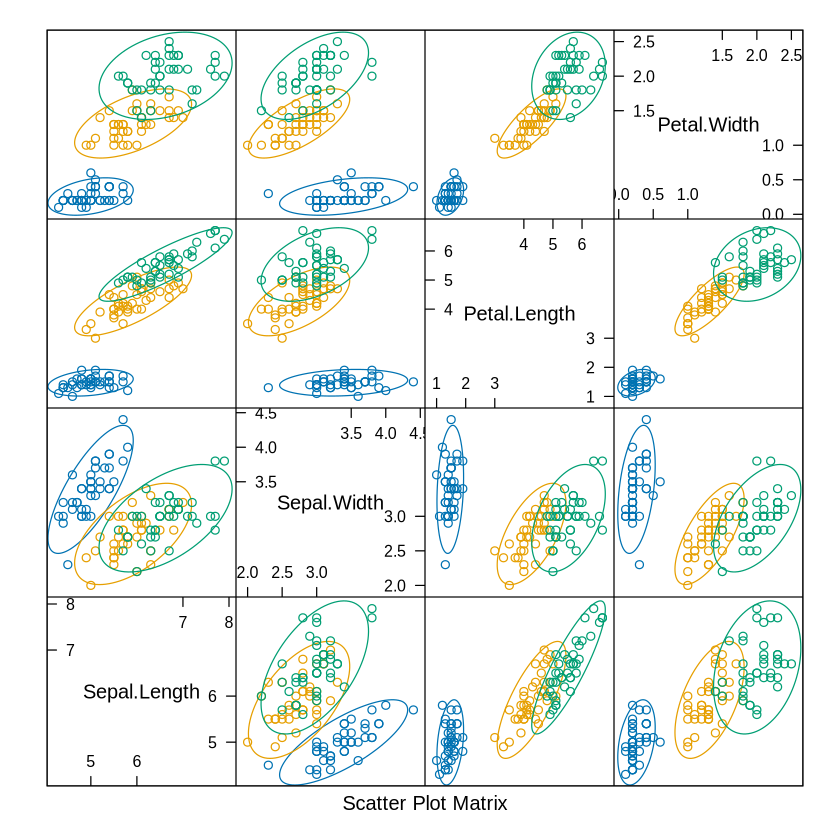

In [5]:
x <- dataset[, 1:4]
y <- dataset[, 5]
featurePlot(x = x, y = y, plot = "ellipse")


## 6. Train Classifiers

Train five models using 10-fold cross-validation on the training set. **Accuracy** is the evaluation metric. Each model uses `set.seed(7)` for reproducibility.


In [6]:
control <- trainControl(method = "cv", number = 10)
metric <- "Accuracy"

set.seed(7)
fit.lda <- train(Species ~ ., data = dataset, method = "lda", metric = metric, trControl = control)

set.seed(7)
fit.cart <- train(Species ~ ., data = dataset, method = "rpart", metric = metric, trControl = control)

set.seed(7)
fit.knn <- train(Species ~ ., data = dataset, method = "knn", metric = metric, trControl = control)

set.seed(7)
fit.svm <- train(Species ~ ., data = dataset, method = "svmRadial", metric = metric, trControl = control)

set.seed(7)
fit.rf <- train(Species ~ ., data = dataset, method = "rf", metric = metric, trControl = control)


## 7. Compare Models

Summarize cross-validation accuracy across all models and plot the results.



Call:
summary.resamples(object = results)

Models: lda, cart, knn, svm, rf 
Number of resamples: 10 

Accuracy 
          Min.   1st Qu.    Median      Mean   3rd Qu. Max. NA's
lda  0.8333333 1.0000000 1.0000000 0.9750000 1.0000000    1    0
cart 0.8333333 0.8541667 0.9166667 0.9166667 0.9791667    1    0
knn  0.8333333 0.9375000 1.0000000 0.9666667 1.0000000    1    0
svm  0.8333333 0.9166667 0.9166667 0.9333333 1.0000000    1    0
rf   0.8333333 0.9166667 1.0000000 0.9500000 1.0000000    1    0

Kappa 
     Min. 1st Qu. Median   Mean 3rd Qu. Max. NA's
lda  0.75 1.00000  1.000 0.9625 1.00000    1    0
cart 0.75 0.78125  0.875 0.8750 0.96875    1    0
knn  0.75 0.90625  1.000 0.9500 1.00000    1    0
svm  0.75 0.87500  0.875 0.9000 1.00000    1    0
rf   0.75 0.87500  1.000 0.9250 1.00000    1    0


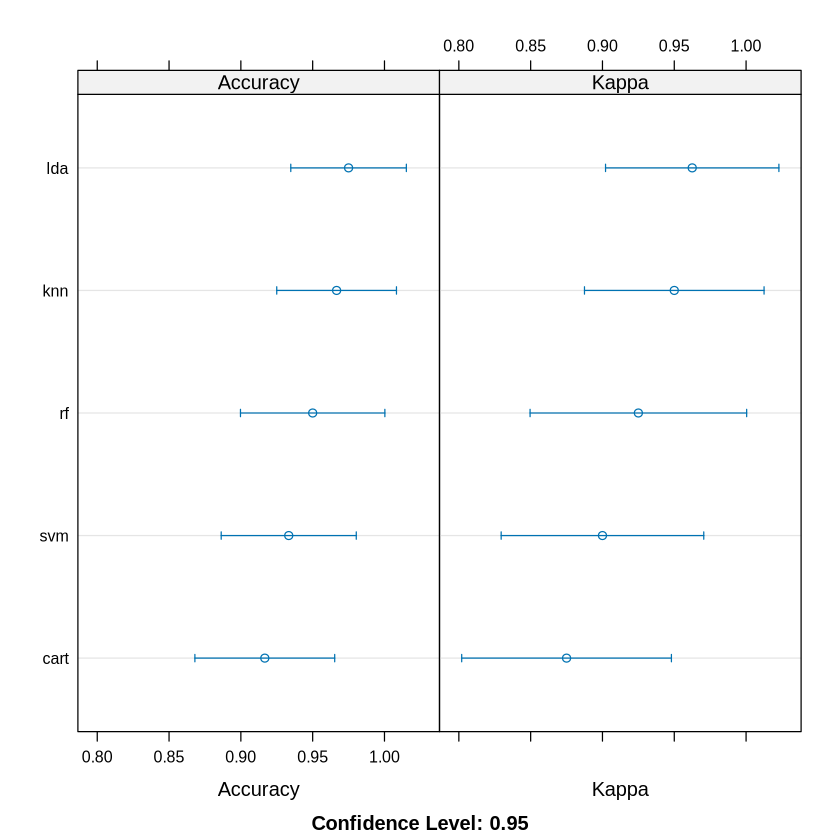

In [7]:
results <- resamples(list(lda = fit.lda, cart = fit.cart, knn = fit.knn, svm = fit.svm, rf = fit.rf))
summary(results)
dotplot(results)


## 8. Select the Best Model

**LDA** has the highest mean cross-validation accuracy (0.975). It is selected as the best model.


In [8]:
best_model <- fit.lda
print(best_model)


Linear Discriminant Analysis 

120 samples
  4 predictor
  3 classes: 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 108, 108, 108, 108, 108, 108, ... 
Resampling results:

  Accuracy  Kappa 
  0.975     0.9625



## 9. Evaluate on the Validation Set

Apply the best model to the held-out 20% validation set and report the confusion matrix.


In [9]:
validation$Species <- as.factor(validation$Species)
predictions <- predict(best_model, validation)
confusionMatrix(predictions, validation$Species)


Confusion Matrix and Statistics

                 Reference
Prediction        Iris-setosa Iris-versicolor Iris-virginica
  Iris-setosa              10               0              0
  Iris-versicolor           0              10              0
  Iris-virginica            0               0             10

Overall Statistics
                                     
               Accuracy : 1          
                 95% CI : (0.8843, 1)
    No Information Rate : 0.3333     
    P-Value [Acc > NIR] : 4.857e-15  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         

Statistics by Class:

                     Class: Iris-setosa Class: Iris-versicolor
Sensitivity                      1.0000                 1.0000
Specificity                      1.0000                 1.0000
Pos Pred Value                   1.0000                 1.0000
Neg Pred Value                   1.0000                 1.0

## 10. Conclusion

Five classifiers were trained on 80% of the Iris data using 10-fold cross-validation. **LDA** achieved the highest mean CV accuracy (97.5%) and perfect accuracy (100%) on the held-out validation set. The Iris dataset is well separated, so a simple linear model performs as well as more complex alternatives for this task.
